# Using magnetic coupling to improve multiple resonance NMR probe

Put `Double-tuned_1H-2H_circuit - Figure B1.json` in the same folder as this notebook.
Install the supplied RF module as `PyORv2/PyOR_RF_Circuits.py` and restart the kernel.

The circuit comes from Figure B1 and Table B1 of A. P. Zens, Journal of Magnetic Resonance 316 (2020), 106741, DOI: 10.1016/j.jmr.2020.106741.
It has two 50 ohm ports. P1 is the high-frequency channel and P2 is the low-frequency channel.
All 23 passive components are loaded from JSON, including the seven stray capacitors.

The internal ideal AC voltage source is suppressed for passive S-parameter analysis.
The paper's Q values are recorded in the JSON as metadata; this simulator uses ideal L/C elements and does not apply those losses.

The module selects a spaced connected layout for this Figure B1 topology. Other general circuits use separated branches with equal node labels indicating electrical connections.


In [1]:
# Define the source path
SourcePath = "/home/vineeth/Documents/PyOR/PyOR"

# Add source path
import sys
sys.path.append(SourcePath)

import time
%matplotlib inline

# Import PyOR package
from PyORv2 import *


*****        ***** *****
*   *        *   * *   *
*****  *   * *   * *****
*       * *  *   * * *  
*        *   ***** *  * 
        *               
       *                
Welcome to Python On Resonance (PyOR)

"In everlasting memory of Gauri, who led me from untruth to Truth, from darkness to Light, and from death to Immortality."

Author: Vineeth Thalakottoor, IE CNRS, LSDRM, CEA, Paris-Saclay

Email: vineeth.thalakottoor@cea.fr

"Everybody can simulate Magnetic Resonance"

Imported modules:

* QuantumSystem          (QuantumSystem from PyOR_QuantumSystem - for single quantum system)
* QuantumSystems         (QuantumSystems from PyOR_QuantumSystems - for multiple quantum systems)
** Hamiltonian           (from PyOR_Hamiltonian)
** DensityMatrix         (from PyOR_DensityMatrix)
** HardPulse             (from PyOR_HardPulse)
** Basis                 (from PyOR_Basis)
** RelaxationProcess     (from PyOR_Relaxation)
** Evolutions            (from PyOR_Evolution)
** Plotting          

In [2]:
# Load ports, components, layout, title and sweep from the JSON file
Json_File = "Double-tuned_1H-2H_circuit - Figure B1.json"
circuit = RFCircuit.Load_Parameters(Json_File)


Double-tuned 1H/2H circuit - Figure B1
Port 1 (P1) -> node N1; reference node P0
Port 2 (P2) -> node N2; reference node P0
All electrical nodes: ['N1', 'N2', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'P0']
Reference impedance: 50.0 Ω


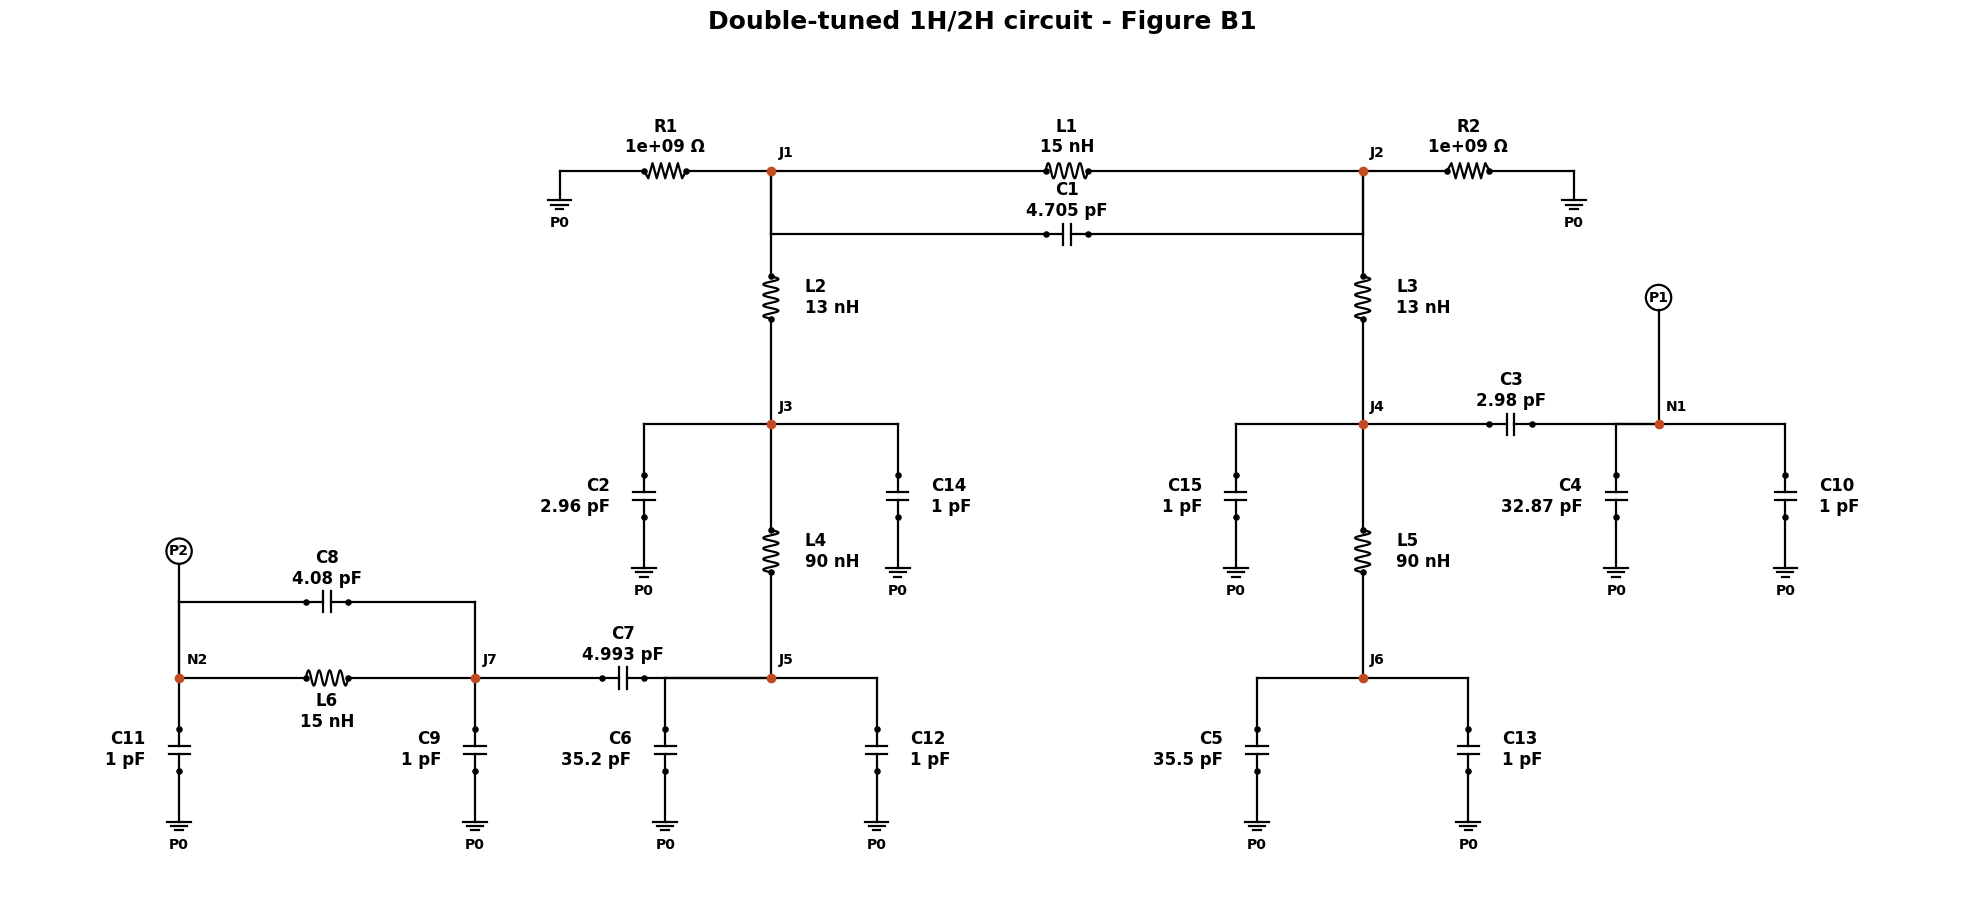

In [3]:
# Draw the circuit
circuit.Plot_Circuit(figsize=(20, 10), font_size=12, node_font_size=10)


In [4]:
# Use the frequency sweep saved in the JSON file
frequency, S = circuit.Simulate()


10,001 frequency samples; S shape = (10001, 2, 2)


## S-parameter magnitude

Frequency limits are in MHz and magnitude limits are in dB.
Change these limits to inspect either channel more closely.


In [5]:
slider_panel = circuit.Plot_Interactive(
    ["S11"],
    xlim=(490, 510),
    ylim=(-160, 5),
    points=5001,
    refine=True,
    markers=(495, 505),  # M1 and M2 frequencies in MHz
)


In [6]:
slider_panel = circuit.Plot_Interactive(
    ["S22"],
    xlim=(50, 100),
    ylim=(-160, 5),
    points=5001,
    refine=True,
    markers=(50, 100),  # M1 and M2 frequencies in MHz
)